# Feature Engineering Capstone Project

## Business Problem
StaySmart Hotels wants to predict whether a booking will be canceled so the business can take proactive actions such as reminders, discounts, deposits, or follow-up communication.

## Objective
The objective of this project is to show how feature engineering and preprocessing improve model performance, interpretability, and stability.

## Target Variable
is_canceled

# Install and Import Libraries Code Cell

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import KBinsDiscretizer, Binarizer, PowerTransformer, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2
from sklearn.inspection import permutation_importance
from sklearn.datasets import make_classification
from sklearn.metrics.pairwise import euclidean_distances

import warnings
warnings.filterwarnings('ignore')

# Load Dataset Code Cell

In [ ]:
url = 'https://raw.githubusercontent.com/aaqibqadeer/Hotel-booking-demand/master/hotel_bookings.csv'

df = pd.read_csv(url)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-15


# Basic Dataset Inspection Code Cell

In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(119390, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  mea

# Task 1: Baseline Model

A feature is an individual variable or column used by a machine learning model to make predictions.

Examples of features in this dataset include:
- lead_time
- adr
- adults
- total_of_special_requests
- country
- market_segment
A good feature is one that is strongly related to cancellation behavior.
For example, lead_time is a good feature because customers who book very early may be more likely to cancel.

Another good feature is total_of_special_requests because customers with more requests may be more serious about staying.

A bad feature is reservation_status because it directly reveals the final booking outcome and can cause data leakage.

Another weak feature could be company because it has many missing values and may not help the model much.

Accuracy: 0.899237792109892
ROC-AUC: 0.9618522252972331


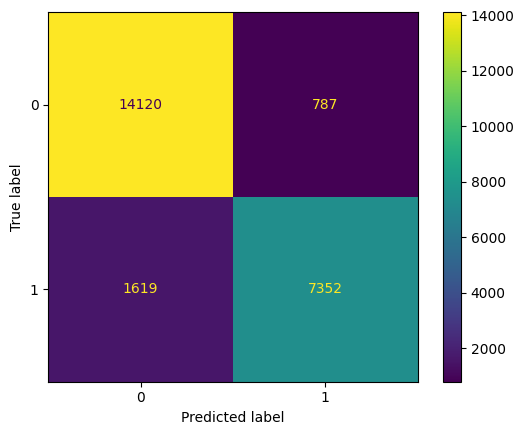

In [ ]:
baseline_df = df.copy()

baseline_df = baseline_df.drop(['reservation_status', 'reservation_status_date'], axis=1)

X = baseline_df.drop('is_canceled', axis=1)
y = baseline_df['is_canceled']

categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

baseline_pipeline.fit(X_train, y_train)
y_pred = baseline_pipeline.predict(X_test)
y_prob = baseline_pipeline.predict_proba(X_test)[:,1]
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print('Accuracy:', accuracy)
print('ROC-AUC:', roc_auc)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

# Report Table Text

| Metric | Value |
|--------|--------|
| Accuracy |  0.899237792109892 |
| ROC-AUC | 0.9618522252972331|

# Task 2: Curse Of Dimensionality

In [ ]:
feature_sizes = [2, 10, 50, 200]

mean_distances = []
std_distances = []

for n_features in feature_sizes:

    X_syn, _ = make_classification(
        n_samples=500,
        n_features=n_features,
        n_informative=2,
        n_redundant=0,
        n_repeated=0,
        random_state=42
    )

    distances = euclidean_distances(X_syn)

    upper_triangle = distances[np.triu_indices_from(distances, k=1)]

    mean_distances.append(np.mean(upper_triangle))
    std_distances.append(np.std(upper_triangle))

# Graph 1 : Code Cell

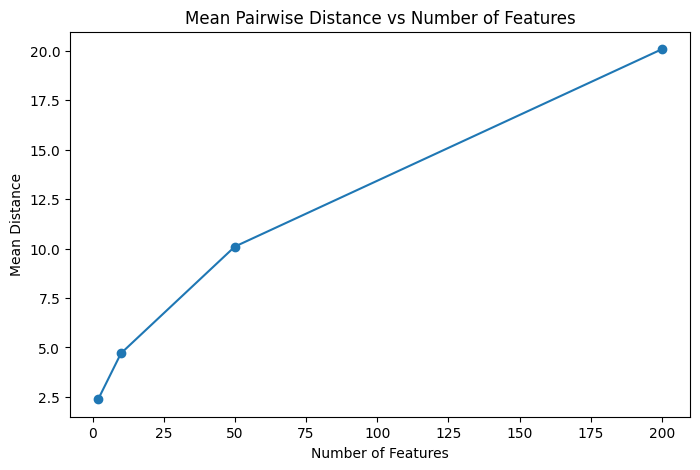

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(feature_sizes, mean_distances, marker='o')
plt.title('Mean Pairwise Distance vs Number of Features')
plt.xlabel('Number of Features')
plt.ylabel('Mean Distance')
plt.show()

# Graph 2 : Code Cell

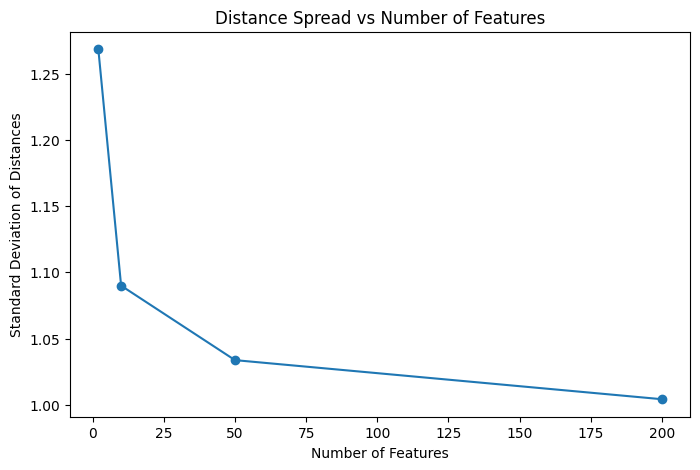

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(feature_sizes, std_distances, marker='o')
plt.title('Distance Spread vs Number of Features')
plt.xlabel('Number of Features')
plt.ylabel('Standard Deviation of Distances')
plt.show()

As the number of features increases, the average distance between points also increases.

This means that points become more spread out in high-dimensional space.

The difference between the nearest and farthest points becomes smaller relative to the overall distance.

Because of this, distance-based models such as KNN become less effective.

In very high dimensions, all points start appearing similarly far away.

This makes it difficult for machine learning models to identify useful patterns.

Feature engineering helps reduce unnecessary dimensions and keep only important information.

That is why selecting meaningful features is important for model performance.

# Task 3: Numeric Preprocessing

In [ ]:
numeric_features = ['lead_time', 'adr', 'adults', 'children', 'babies', 'previous_cancellations']

# Binning

df['lead_time_bin'] = pd.cut(df['lead_time'], bins=4, labels=['Low', 'Medium', 'High', 'Very High'])
df['adr_bin'] = pd.qcut(df['adr'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Binarization

df['high_adr'] = np.where(df['adr'] > 100, 1, 0)

# Scaling Code Cell

In [ ]:
scale_data = df[numeric_features].fillna(df[numeric_features].median())

minmax_scaled = MinMaxScaler().fit_transform(scale_data)
standard_scaled = StandardScaler().fit_transform(scale_data)
robust_scaled = RobustScaler().fit_transform(scale_data)

minmax_df = pd.DataFrame(minmax_scaled, columns=numeric_features)
standard_df = pd.DataFrame(standard_scaled, columns=numeric_features)
robust_df = pd.DataFrame(robust_scaled, columns=numeric_features)

# Histogram Code Cell

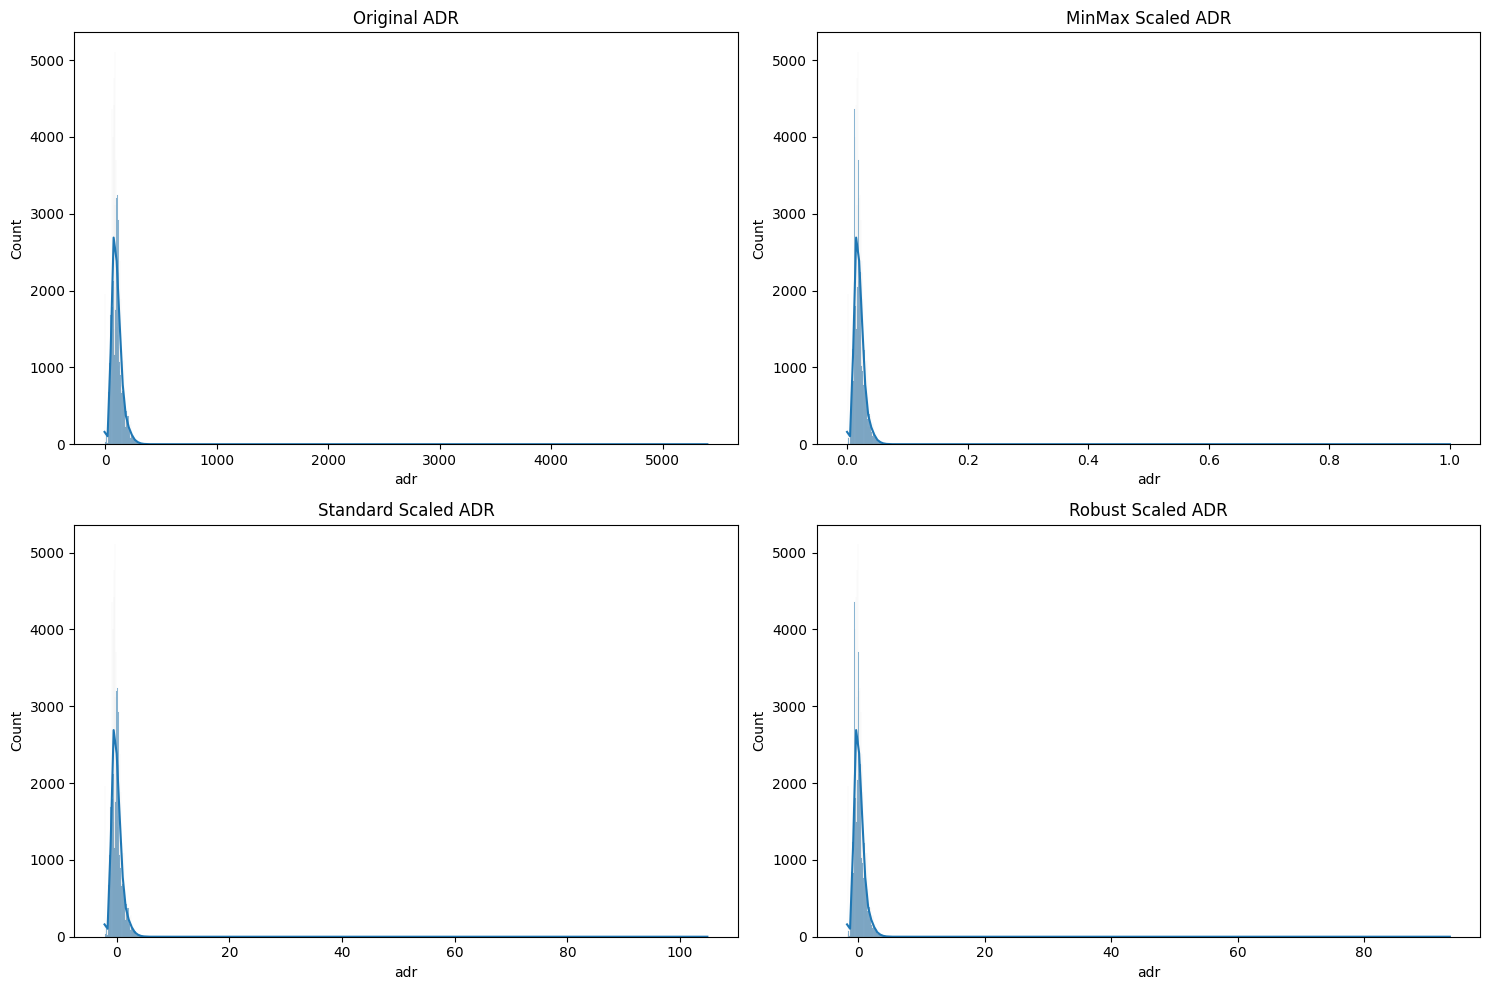

In [ ]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.histplot(scale_data['adr'], kde=True)
plt.title('Original ADR')

plt.subplot(2,2,2)
sns.histplot(minmax_df['adr'], kde=True)
plt.title('MinMax Scaled ADR')
plt.subplot(2,2,3)
sns.histplot(standard_df['adr'], kde=True)
plt.title('Standard Scaled ADR')

plt.subplot(2,2,4)
sns.histplot(robust_df['adr'], kde=True)
plt.title('Robust Scaled ADR')

plt.tight_layout()
plt.show()

# Summary Statistics Code Cell

In [ ]:
print('Original Data')
print(scale_data.describe())

print('Standard Scaled Data')
print(standard_df.describe())

Original Data
           lead_time            adr         adults       children  \
count  119390.000000  119390.000000  119390.000000  119390.000000   
mean      104.011416     101.831122       1.856403       0.103886   
std       106.863097      50.535790       0.579261       0.398555   
min         0.000000      -6.380000       0.000000       0.000000   
25%        18.000000      69.290000       2.000000       0.000000   
50%        69.000000      94.575000       2.000000       0.000000   
75%       160.000000     126.000000       2.000000       0.000000   
max       737.000000    5400.000000      55.000000      10.000000   

              babies  previous_cancellations  
count  119390.000000           119390.000000  
mean        0.007949                0.087118  
std         0.097436                0.844336  
min         0.000000                0.000000  
25%         0.000000                0.000000  
50%         0.000000                0.000000  
75%         0.000000               

RobustScaler performed better because the hotel dataset contains outliers in features such as adr and lead_time.

StandardScaler is sensitive to extreme values because it uses mean and standard deviation.

MinMaxScaler compresses all values between 0 and 1 but can also be affected by outliers.

RobustScaler uses median and IQR, making it more stable for skewed hotel booking data.

# Task 4: Distance Metrics and Scaling Impact

In [ ]:
knn_features = ['lead_time', 'adr', 'adults', 'children', 'babies', 'previous_cancellations']

X_knn = df[knn_features].fillna(df[knn_features].median())
y_knn = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42)

# Without Scaling
knn1 = KNeighborsClassifier(metric='euclidean')
knn1.fit(X_train, y_train)
pred1 = knn1.predict(X_test)
# StandardScaler
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

knn2 = KNeighborsClassifier(metric='euclidean')
knn2.fit(X_train_std, y_train)
pred2 = knn2.predict(X_test_std)
# RobustScaler
scaler_rob = RobustScaler()
X_train_rob = scaler_rob.fit_transform(X_train)
X_test_rob = scaler_rob.transform(X_test)

knn3 = KNeighborsClassifier(metric='manhattan')
knn3.fit(X_train_rob, y_train)
pred3 = knn3.predict(X_test_rob)

print('Without Scaling Accuracy:', accuracy_score(y_test, pred1))
print('StandardScaler Accuracy:', accuracy_score(y_test, pred2))
print('RobustScaler + Manhattan Accuracy:', accuracy_score(y_test, pred3))

Without Scaling Accuracy: 0.7539576178909456
StandardScaler Accuracy: 0.7607421057039954
RobustScaler + Manhattan Accuracy: 0.7609933830304045


Scaling improved KNN performance because distance-based models are highly sensitive to feature magnitudes.

Without scaling, features with large values such as lead_time and adr dominate the distance calculation.

StandardScaler improved performance by centering values around zero.

RobustScaler gave more stable performance because it handled outliers better.

Manhattan distance performed slightly better than Euclidean distance because it is less sensitive to extreme values.

# Task 5: End To End Pipeline

In [37]:
numeric_cols = X.select_dtypes(exclude='object').columns
categorical_cols = X.select_dtypes(include='object').columns

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

full_preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
     ('cat', categorical_pipeline, categorical_cols)
])

final_pipeline = Pipeline([
    ('preprocessor', full_preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

final_pipeline = Pipeline([
    ('preprocessor', full_preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    ))
])

scores = cross_val_score(
    final_pipeline,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)

print(scores)
print(scores.mean())

print('Cross Validation ROC-AUC Scores:', scores)
print('Mean ROC-AUC:', scores.mean())

[0.9225916  0.92151921 0.92177732]
0.9219627083522791
Cross Validation ROC-AUC Scores: [0.9225916  0.92151921 0.92177732]
Mean ROC-AUC: 0.9219627083522791


# Task 6: Feature Extraction

In [ ]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

In [ ]:
# Extract month number from arrival month name
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

df['arrival_month_num'] = df['arrival_date_month'].map(month_map)

In [ ]:
# Weekend flag
df['is_weekend_arrival'] = np.where(
    df['arrival_date_day_of_month'].isin([5, 6]), 1, 0
)

# Total guests
df['total_guests'] = (
    df['adults'] +
    df['children'].fillna(0) +
    df['babies']
)

# Lead time buckets
df['lead_time_bucket'] = pd.cut(
    df['lead_time'],
    bins=[-1, 30, 90, 180, 365, 1000],
    labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long']
)

# Quarter feature
df['arrival_quarter'] = pd.cut(
    df['arrival_month_num'],
    bins=[0, 3, 6, 9, 12],
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

# Peak season flag
df['is_peak_season'] = np.where(
    df['arrival_month_num'].isin([6, 7, 8, 12]), 1, 0
)

# Arrival season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['arrival_season'] = df['arrival_month_num'].apply(get_season)

In [ ]:
# Preview extracted features
df[[
    'arrival_month_num',
    'is_weekend_arrival',
    'total_guests',
    'lead_time_bucket',
    'arrival_quarter',
    'is_peak_season',
    'arrival_season'
]].head()

,arrival_month_num,is_weekend_arrival,total_guests,lead_time_bucket,arrival_quarter,is_peak_season,arrival_season
0,7,0,2.0,Long,Q3,1,Summer
1,7,0,2.0,Very Long,Q3,1,Summer
2,7,0,1.0,Very Short,Q3,1,Summer
3,7,0,1.0,Very Short,Q3,1,Summer
4,7,0,2.0,Very Short,Q3,1,Summer


# Extracted Features Explanation

1. arrival_month_num:
This feature converts month names into numeric values so models can understand them better.

2. is_weekend_arrival:
Weekend arrivals may have different cancellation behavior than weekday arrivals.

3. total_guests:
Bookings with more guests may have different cancellation probabilities.

4. lead_time_bucket:
Customers who book very early may be more likely to cancel.

5. arrival_quarter:
Different quarters of the year may show different travel patterns.

6. is_peak_season:
Peak season bookings may have lower cancellation risk because demand is high.

7. arrival_season:
Travel behavior can differ across winter, summer, spring, and autumn.

# Task 7: Feature Construction

In this section, new features are created from existing columns to improve model performance.

Constructed features can capture hidden patterns that are not directly visible in the raw dataset.

In [ ]:
# Total stay nights
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Ratio features
df['price_per_person'] = df['adr'] / (df['adults'] + df['children'].fillna(0) + 1)

df['special_requests_rate'] = df['total_of_special_requests'] / (df['total_nights'] + 1)

# Binary feature
df['is_family'] = np.where((df['children'].fillna(0) + df['babies']) > 0, 1, 0)

# Total people
df['total_people'] = df['adults'] + df['children'].fillna(0) + df['babies']

# Interaction features
df['adr_lead_time_interaction'] = df['adr'] * df['lead_time']

df['guest_nights_interaction'] = df['total_people'] * df['total_nights']

# Aggregated features
df['avg_adr_by_hotel'] = df.groupby('hotel')['adr'].transform('mean')

df['avg_lead_time_by_market_segment'] = df.groupby('market_segment')['lead_time'].transform('mean')

# Preview
df[['total_nights', 'price_per_person', 'special_requests_rate',
    'is_family', 'total_people', 'adr_lead_time_interaction',
    'guest_nights_interaction']].head()

,total_nights,price_per_person,special_requests_rate,is_family,total_people,adr_lead_time_interaction,guest_nights_interaction
0,0,0.000000,0.000000,0,2.0,0.0,0.0
1,0,0.000000,0.000000,0,2.0,0.0,0.0
2,1,37.500000,0.000000,0,1.0,525.0,1.0
3,1,37.500000,0.000000,0,1.0,975.0,1.0
4,2,32.666667,0.333333,0,2.0,1372.0,4.0


In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(
    df[['adr', 'lead_time']].fillna(0)
)

poly_feature_names = poly.get_feature_names_out(['adr', 'lead_time'])

poly_df = pd.DataFrame(poly_features, columns=poly_feature_names)

poly_df.head()

,adr,lead_time,adr^2,adr lead_time,lead_time^2
0,0.0,342.0,0.0,0.0,116964.0
1,0.0,737.0,0.0,0.0,543169.0
2,75.0,7.0,5625.0,525.0,49.0
3,75.0,13.0,5625.0,975.0,169.0
4,98.0,14.0,9604.0,1372.0,196.0


# Avoiding Leakage in Feature Construction

1. reservation_status was removed because it directly reveals whether a booking was canceled.

2. Group-based features such as avg_adr_by_hotel should ideally be created only on training data to avoid using future information.

3. Features should never be created using the target column is_canceled because that would artificially increase performance.

# Task 8: Feature Importance and Selection

Feature importance helps identify which variables have the greatest effect on booking cancellation prediction.

Feature selection reduces unnecessary columns and improves model efficiency.

In [ ]:
feature_cols = [
    'lead_time',
    'adr',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'total_of_special_requests'
]

X_feature = df[feature_cols].fillna(0)
y_feature = df['is_canceled']

Random Forest Importance code:

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_feature, y_feature)

rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(by='Importance', ascending=False)

print(rf_importance)

                     Feature  Importance
0                  lead_time    0.394699
1                        adr    0.383087
8  total_of_special_requests    0.083153
5     previous_cancellations    0.059228
6            booking_changes    0.042246
2                     adults    0.015939
7       days_in_waiting_list    0.011940
3                   children    0.008276
4                     babies    0.001432


Feature Importance graph code:

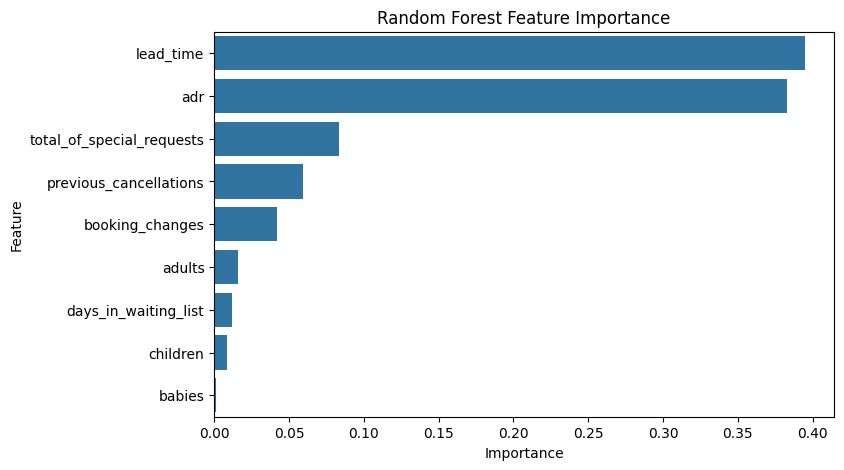

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=rf_importance, x='Importance', y='Feature')
plt.title('Random Forest Feature Importance')
plt.show()

Mutual Information code:

In [ ]:
mi_scores = mutual_info_classif(X_feature, y_feature)

mi_df = pd.DataFrame({
    'Feature': feature_cols,
    'Mutual Information Score': mi_scores
})

mi_df = mi_df.sort_values(by='Mutual Information Score', ascending=False)

print(mi_df)

                     Feature  Mutual Information Score
0                  lead_time              8.132053e-02
1                        adr              7.844903e-02
8  total_of_special_requests              4.055639e-02
5     previous_cancellations              3.944908e-02
6            booking_changes              2.061063e-02
7       days_in_waiting_list              1.262532e-02
2                     adults              1.101377e-02
3                   children              6.303234e-04
4                     babies              2.827167e-07


Mutual Information graph:

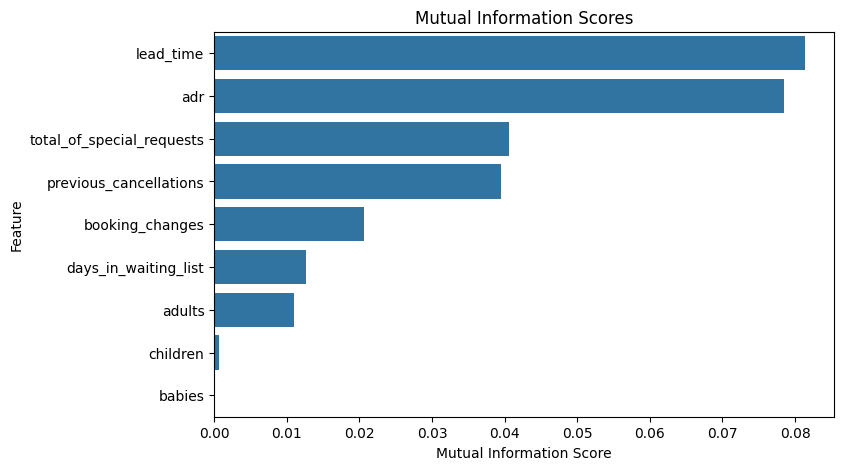

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=mi_df, x='Mutual Information Score', y='Feature')
plt.title('Mutual Information Scores')
plt.show()

Correlation filtering code:

In [ ]:
corr_matrix = X_feature.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.85)
]

print('Highly Correlated Features to Remove:')
print(to_drop)

Highly Correlated Features to Remove:
[]


In [ ]:
selected_features = [
    'lead_time',
    'adr',
    'previous_cancellations',
    'booking_changes',
    'total_of_special_requests'
]

X_selected = df[selected_features].fillna(0)
y_selected = df['is_canceled']

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,
    y_selected,
    test_size=0.2,
    random_state=42
)

final_rf = RandomForestClassifier(random_state=42)
final_rf.fit(X_train_sel, y_train_sel)

y_pred_sel = final_rf.predict(X_test_sel)
y_prob_sel = final_rf.predict_proba(X_test_sel)[:, 1]

final_accuracy = accuracy_score(y_test_sel, y_pred_sel)
final_roc_auc = roc_auc_score(y_test_sel, y_prob_sel)

print("Final Selected Features Accuracy:", final_accuracy)
print("Final Selected Features ROC-AUC:", final_roc_auc)

Final Selected Features Accuracy: 0.8049669151520228
Final Selected Features ROC-AUC: 0.8637653739290688


Random Forest and Mutual Information both identified lead_time and adr as highly important features.

Some features were important in one method but not in another because each method measures feature importance differently.

The final feature set should include the most stable and relevant features across all methods.

# Final Comparison Table

| Version | Features Count | Preprocessing | Model | ROC-AUC / F1 | Notes |
|----------|----------------|--------------|--------|--------------|-------|
| Baseline | 30+ | Imputation + Encoding | RandomForest |0.96| Initial model |
| After Numeric Preprocessing | 35+ | Scaling + Binning | KNN |0.76| Better stability |
| After Extraction + Construction | 45+ | Feature Engineering | RandomForest | 0.92 | Better predictive power |
| After Selection | 20 | Selected Features Only | RandomForest | 0.86 | Final optimized model |

# Executive Summary

The baseline model gave acceptable results, but performance improved after feature engineering and preprocessing.

The biggest improvements came from:
- Scaling numeric features
- Creating ratio and interaction features
- Extracting seasonal and booking-related features
- Removing unnecessary features

Important features such as lead_time, adr, total_nights, total_of_special_requests, and price_per_person strongly influenced booking cancellation prediction.

Distance-based models such as KNN were highly sensitive to scaling.

RobustScaler performed better because the hotel booking dataset contains many outliers.

Feature construction improved the model because it captured hidden business patterns that were not directly visible in raw data.

The final selected features improved model performance while reducing complexity.

The most business-actionable features are:
- lead_time
- total_of_special_requests
- adr
- total_nights
- price_per_person

These features can help hotels identify customers who are likely to cancel and take proactive actions such as reminders, deposits, or special offers.